# ROGII v3: Residual-Calibrated TVT Model



In [2]:
# Configuration
DATA_DIR = None
OUTPUT_PATH = 'submission.csv'
MODEL_DIR = 'models'

MAX_TRAIN_ROWS = 800_000
CALIBRATION_ROWS = 220_000
VALIDATION_FRACTION = 0.18


In [3]:
from __future__ import annotations

import argparse
import json
import pickle
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Sequence, Tuple

import numpy as np
import pandas as pd


TARGET = "TVT"
SUB_TARGET = "tvt"
COMMON_NUMERIC = ["MD", "X", "Y", "Z", "GR", "TVT_input"]
WINDOWS = [25, 100, 300, 1000]
VERSION = "rogii_v3_residual_calibrated"


def find_data_dir(user_path: str | None = None) -> Path:
    candidates = []
    if user_path:
        candidates.append(Path(user_path))
    candidates.extend(
        [
            Path("/kaggle/input/rogii-wellbore-geology-prediction"),
            Path("../input/rogii-wellbore-geology-prediction"),
            Path("rogii-wellbore-geology-prediction"),
            Path.cwd() / "rogii-wellbore-geology-prediction",
        ]
    )
    for path in candidates:
        if (path / "train").exists() and (path / "test").exists() and (path / "sample_submission.csv").exists():
            return path

    search_roots = [Path("/kaggle/input"), Path.cwd(), Path.cwd().parent]
    seen = set()
    for root in search_roots:
        if not root.exists():
            continue
        for sample_path in root.rglob("sample_submission.csv"):
            data_dir = sample_path.parent
            key = str(data_dir.resolve())
            if key in seen:
                continue
            seen.add(key)
            if (data_dir / "train").exists() and (data_dir / "test").exists():
                return data_dir

    if Path("/kaggle/input").exists():
        available = [str(p) for p in Path("/kaggle/input").iterdir()]
        raise FileNotFoundError(f"Could not find data directory. /kaggle/input contains: {available}")
    raise FileNotFoundError("Could not find the competition data directory.")


def save_object(obj: Any, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        import joblib

        joblib.dump(obj, path)
    except Exception:
        with path.open("wb") as f:
            pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)


def safe_slope(x: np.ndarray, y: np.ndarray) -> float:
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return 0.0
    x = x[mask]
    y = y[mask]
    denom = np.var(x)
    if denom <= 1e-12:
        return 0.0
    return float(np.cov(x, y, bias=True)[0, 1] / denom)


def interpolate_tvt_input(df: pd.DataFrame) -> pd.Series:
    values = pd.to_numeric(df.get("TVT_input"), errors="coerce")
    if values.notna().sum() == 0:
        return pd.Series(np.full(len(df), np.nan), index=df.index)
    x = np.arange(len(df), dtype=float)
    known = values.notna().to_numpy()
    filled = np.interp(x, x[known], values.to_numpy(dtype=float)[known])
    return pd.Series(filled, index=df.index)


def tail_features(df: pd.DataFrame) -> Dict[str, float]:
    known = df["TVT_input"].notna().to_numpy()
    out: Dict[str, float] = {}
    if known.sum() == 0:
        for window in WINDOWS:
            out[f"tail_slope_row_{window}"] = 0.0
            out[f"tail_slope_md_{window}"] = 0.0
            out[f"tail_slope_z_{window}"] = 0.0
        out.update(
            {
                "first_missing_row": 0.0,
                "last_known_row": 0.0,
                "last_known_md": np.nan,
                "last_known_z": np.nan,
                "last_known_tvt": np.nan,
                "last_known_gr": np.nan,
                "known_tvt_mean": np.nan,
                "known_tvt_std": np.nan,
            }
        )
        return out

    known_idx = np.flatnonzero(known)
    last_idx = int(known_idx[-1])
    tvt_known = df.loc[known_idx, "TVT_input"].to_numpy(dtype=float)
    out.update(
        {
            "first_missing_row": float(last_idx + 1),
            "last_known_row": float(last_idx),
            "last_known_md": float(df.loc[last_idx, "MD"]),
            "last_known_z": float(df.loc[last_idx, "Z"]),
            "last_known_tvt": float(df.loc[last_idx, "TVT_input"]),
            "last_known_gr": float(df.loc[last_idx, "GR"]) if pd.notna(df.loc[last_idx, "GR"]) else np.nan,
            "known_tvt_mean": float(np.nanmean(tvt_known)),
            "known_tvt_std": float(np.nanstd(tvt_known)),
        }
    )

    for window in WINDOWS:
        idx = known_idx[-min(window, len(known_idx)) :]
        y = df.loc[idx, "TVT_input"].to_numpy(dtype=float)
        out[f"tail_slope_row_{window}"] = safe_slope(idx.astype(float), y)
        out[f"tail_slope_md_{window}"] = safe_slope(df.loc[idx, "MD"].to_numpy(dtype=float), y)
        out[f"tail_slope_z_{window}"] = safe_slope(df.loc[idx, "Z"].to_numpy(dtype=float), y)
    return out


def typewell_features(path: Path) -> Dict[str, float]:
    defaults = {
        "type_tvt_min": np.nan,
        "type_tvt_max": np.nan,
        "type_tvt_mean": np.nan,
        "type_tvt_std": np.nan,
        "type_gr_mean": np.nan,
        "type_gr_std": np.nan,
        "type_gr_p05": np.nan,
        "type_gr_p10": np.nan,
        "type_gr_p50": np.nan,
        "type_gr_p90": np.nan,
        "type_gr_p95": np.nan,
        "type_gr_slope": np.nan,
        "type_geology_nunique": 0.0,
    }
    if not path.exists():
        return defaults

    tw = pd.read_csv(path)
    for col in ["TVT", "GR"]:
        if col in tw:
            tw[col] = pd.to_numeric(tw[col], errors="coerce")

    out = defaults.copy()
    if "TVT" in tw:
        out.update(
            {
                "type_tvt_min": tw["TVT"].min(),
                "type_tvt_max": tw["TVT"].max(),
                "type_tvt_mean": tw["TVT"].mean(),
                "type_tvt_std": tw["TVT"].std(),
            }
        )
    if "GR" in tw:
        out.update(
            {
                "type_gr_mean": tw["GR"].mean(),
                "type_gr_std": tw["GR"].std(),
                "type_gr_p05": tw["GR"].quantile(0.05),
                "type_gr_p10": tw["GR"].quantile(0.10),
                "type_gr_p50": tw["GR"].quantile(0.50),
                "type_gr_p90": tw["GR"].quantile(0.90),
                "type_gr_p95": tw["GR"].quantile(0.95),
            }
        )
    if {"TVT", "GR"}.issubset(tw.columns):
        out["type_gr_slope"] = safe_slope(tw["TVT"].to_numpy(), tw["GR"].to_numpy())
    if "Geology" in tw:
        out["type_geology_nunique"] = float(tw["Geology"].nunique(dropna=True))
    return out


def add_well_features(df: pd.DataFrame, well_id: str, tw_feats: Dict[str, float]) -> pd.DataFrame:
    out = df.copy()
    for col in COMMON_NUMERIC:
        if col not in out:
            out[col] = np.nan
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out["well_id"] = well_id
    out["row_index"] = np.arange(len(out), dtype=np.int32)
    out["rel_row"] = out["row_index"] / max(len(out) - 1, 1)
    out["tvt_input_known"] = out["TVT_input"].notna().astype(np.int8)
    out["tvt_input_interp"] = interpolate_tvt_input(out)

    tf = tail_features(out)
    for key, value in tf.items():
        out[key] = value

    out["md_from_start"] = out["MD"] - out["MD"].min()
    out["md_to_end"] = out["MD"].max() - out["MD"]
    out["rows_after_known"] = out["row_index"] - out["last_known_row"]
    out["md_after_known"] = out["MD"] - out["last_known_md"]
    out["z_after_known"] = out["Z"] - out["last_known_z"]
    out["gr_after_known"] = out["GR"] - out["last_known_gr"]
    out["z_minus_last_tvt"] = out["Z"] - out["last_known_tvt"]
    out["md_minus_last_tvt"] = out["MD"] - out["last_known_tvt"]

    for col in ["MD", "X", "Y", "Z", "GR", "tvt_input_interp"]:
        series = out[col].astype(float)
        out[f"{col}_diff1"] = series.diff().fillna(0.0)
        out[f"{col}_diff5"] = (series - series.shift(5)).fillna(0.0)

    out["gr_roll_mean_7"] = out["GR"].rolling(7, min_periods=1, center=True).mean()
    out["gr_roll_std_15"] = out["GR"].rolling(15, min_periods=2, center=True).std().fillna(0.0)
    out["gr_roll_mean_51"] = out["GR"].rolling(51, min_periods=1, center=True).mean()
    out["gr_roll_std_101"] = out["GR"].rolling(101, min_periods=2, center=True).std().fillna(0.0)

    for window in WINDOWS:
        out[f"tvt_tail_row_{window}"] = out["last_known_tvt"] + out[f"tail_slope_row_{window}"] * out["rows_after_known"]
        out[f"tvt_tail_md_{window}"] = out["last_known_tvt"] + out[f"tail_slope_md_{window}"] * out["md_after_known"]
        out[f"tvt_tail_z_{window}"] = out["last_known_tvt"] + out[f"tail_slope_z_{window}"] * out["z_after_known"]
        out[f"tail_md_resid_{window}"] = out[f"tvt_tail_md_{window}"] - out["last_known_tvt"]

    for key, value in tw_feats.items():
        out[key] = value
    out["last_tvt_minus_type_mean"] = out["last_known_tvt"] - out["type_tvt_mean"]
    out["gr_minus_type_mean"] = out["GR"] - out["type_gr_mean"]
    out["gr_roll_minus_type_p50"] = out["gr_roll_mean_51"] - out["type_gr_p50"]

    float_cols = out.select_dtypes(include=["float64"]).columns
    out[float_cols] = out[float_cols].astype("float32")
    return out


def load_split(data_dir: Path, split: str) -> pd.DataFrame:
    frames = []
    for h_path in sorted((data_dir / split).glob("*__horizontal_well.csv")):
        well_id = h_path.name.split("__")[0]
        tw_path = data_dir / split / f"{well_id}__typewell.csv"
        df = pd.read_csv(h_path)
        frames.append(add_well_features(df, well_id, typewell_features(tw_path)))
    if not frames:
        raise FileNotFoundError(f"No horizontal well files found in {data_dir / split}")
    data = pd.concat(frames, ignore_index=True)
    data["well_id"] = data["well_id"].astype("category")
    return data


def feature_columns(train: pd.DataFrame, test: pd.DataFrame, candidate_idx: np.ndarray) -> List[str]:
    blocked = {TARGET, "well_id"}
    features = []
    for col in train.columns:
        if col in blocked or col not in test.columns:
            continue
        if not pd.api.types.is_numeric_dtype(train[col]):
            continue
        observed = train.loc[candidate_idx, col].notna().any()
        if observed:
            features.append(col)
    return features


def deterministic_well_split(wells: pd.Series, validation_fraction: float) -> np.ndarray:
    values = []
    threshold = int(validation_fraction * 10_000)
    for well in wells.astype(str):
        value = sum((i + 1) * ord(ch) for i, ch in enumerate(well)) % 10_000
        values.append(value < threshold)
    return np.asarray(values, dtype=bool)


def sample_indices(idx: np.ndarray, max_rows: int, seed: int) -> np.ndarray:
    if len(idx) <= max_rows:
        return np.sort(idx)
    rng = np.random.default_rng(seed)
    sampled = rng.choice(idx, size=max_rows, replace=False)
    return np.sort(sampled)


@dataclass
class ModelBundle:
    models: List[Tuple[str, Any]]
    features: List[str]
    alpha: float
    bias: float
    residual_clip: Tuple[float, float]
    metadata: Dict[str, Any]


def build_model_candidates(seed: int = 42) -> List[Tuple[str, Any]]:
    candidates: List[Tuple[str, Any]] = []
    try:
        from lightgbm import LGBMRegressor

        candidates.append(
            (
                "lightgbm",
                LGBMRegressor(
                    objective="regression_l1",
                    n_estimators=1800,
                    learning_rate=0.035,
                    num_leaves=63,
                    min_child_samples=70,
                    subsample=0.86,
                    colsample_bytree=0.86,
                    reg_alpha=0.05,
                    reg_lambda=0.30,
                    random_state=seed,
                    n_jobs=-1,
                    verbosity=-1,
                ),
            )
        )
    except Exception:
        pass

    try:
        from xgboost import XGBRegressor

        candidates.append(
            (
                "xgboost",
                XGBRegressor(
                    objective="reg:absoluteerror",
                    n_estimators=900,
                    learning_rate=0.035,
                    max_depth=7,
                    subsample=0.86,
                    colsample_bytree=0.86,
                    reg_alpha=0.02,
                    reg_lambda=1.0,
                    tree_method="hist",
                    random_state=seed + 1,
                    n_jobs=-1,
                ),
            )
        )
    except Exception:
        pass

    if candidates:
        return candidates

    try:
        from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
        from sklearn.impute import SimpleImputer
        from sklearn.pipeline import make_pipeline

        candidates.extend(
            [
                (
                    "hist_gradient_boosting",
                    make_pipeline(
                        SimpleImputer(strategy="median"),
                        HistGradientBoostingRegressor(
                            max_iter=650,
                            learning_rate=0.045,
                            l2_regularization=0.03,
                            max_leaf_nodes=31,
                            random_state=seed,
                        ),
                    ),
                ),
                (
                    "extra_trees",
                    make_pipeline(
                        SimpleImputer(strategy="median"),
                        ExtraTreesRegressor(
                            n_estimators=500,
                            max_features=0.75,
                            min_samples_leaf=2,
                            n_jobs=-1,
                            random_state=seed + 2,
                        ),
                    ),
                ),
            ]
        )
    except Exception:
        pass
    return candidates


def fit_models(models: List[Tuple[str, Any]], x: pd.DataFrame, y: pd.Series) -> List[Tuple[str, Any]]:
    fitted = []
    for name, model in models:
        print(f"fitting {name} on {len(x):,} rows and {x.shape[1]} features")
        model.fit(x, y)
        fitted.append((name, model))
    return fitted


def predict_residual(models: Sequence[Tuple[str, Any]], x: pd.DataFrame) -> np.ndarray:
    if not models:
        return np.zeros(len(x), dtype=float)
    weights = []
    preds = []
    for name, model in models:
        pred = np.asarray(model.predict(x), dtype=float)
        weight = 0.65 if name == "lightgbm" else 0.35 if name == "xgboost" else 0.50
        weights.append(weight)
        preds.append(pred)
    weights_arr = np.asarray(weights, dtype=float)
    weights_arr = weights_arr / weights_arr.sum()
    return np.sum([w * p for w, p in zip(weights_arr, preds)], axis=0)


def calibrate_residual(
    true_tvt: pd.Series,
    baseline: pd.Series,
    residual_pred: np.ndarray,
    residual_train: pd.Series,
) -> Tuple[float, float, Tuple[float, float], float]:
    clip_lo, clip_hi = np.nanpercentile(residual_train.to_numpy(dtype=float), [0.5, 99.5])
    residual_pred = np.clip(residual_pred, clip_lo, clip_hi)
    true = true_tvt.to_numpy(dtype=float)
    base = baseline.to_numpy(dtype=float)

    best_alpha = 0.0
    best_bias = 0.0
    best_mae = float(np.mean(np.abs(true - base)))
    for alpha in np.linspace(0.0, 1.0, 21):
        raw = alpha * residual_pred
        bias = float(np.nanmedian(true - (base + raw)))
        pred = base + raw + bias
        mae = float(np.mean(np.abs(true - pred)))
        if mae < best_mae:
            best_alpha = float(alpha)
            best_bias = bias
            best_mae = mae
    return best_alpha, best_bias, (float(clip_lo), float(clip_hi)), best_mae


def train_bundle(
    train: pd.DataFrame,
    test: pd.DataFrame,
    max_train_rows: int,
    calibration_rows: int,
    validation_fraction: float,
) -> ModelBundle:
    y = pd.to_numeric(train[TARGET], errors="coerce")
    target_mask = y.notna() & train["TVT_input"].isna() & train["last_known_tvt"].notna()
    if target_mask.sum() == 0:
        target_mask = y.notna() & train["last_known_tvt"].notna()
        print("No TVT_input-missing rows found; training on all labeled rows.")

    target_idx = train.index[target_mask].to_numpy()
    val_wells = deterministic_well_split(train.loc[target_idx, "well_id"], validation_fraction)
    val_idx_all = target_idx[val_wells]
    fit_idx_all = target_idx[~val_wells]
    if len(val_idx_all) == 0 or len(fit_idx_all) == 0:
        val_idx_all = target_idx[::5]
        fit_idx_all = np.setdiff1d(target_idx, val_idx_all)

    val_idx = sample_indices(val_idx_all, calibration_rows, seed=7)
    calibration_fit_rows = max(50_000, min(max_train_rows // 2, max_train_rows - len(val_idx)))
    fit_idx = sample_indices(fit_idx_all, calibration_fit_rows, seed=42)

    features = feature_columns(train, test, fit_idx)
    print(f"usable features: {len(features)}")

    residual = y - train["last_known_tvt"]
    models = build_model_candidates(seed=42)
    if not models:
        print("No model library found. Saving baseline-only bundle.")
        baseline_mae = float(np.mean(np.abs(y.loc[val_idx] - train.loc[val_idx, "last_known_tvt"]))) if len(val_idx) else np.nan
        return ModelBundle(
            models=[],
            features=features,
            alpha=0.0,
            bias=0.0,
            residual_clip=(0.0, 0.0),
            metadata={"version": VERSION, "mode": "baseline_only", "validation_mae": baseline_mae},
        )

    x_fit = train.loc[fit_idx, features].replace([np.inf, -np.inf], np.nan)
    y_fit = residual.loc[fit_idx]
    fitted_calibration = fit_models(models, x_fit, y_fit)

    x_val = train.loc[val_idx, features].replace([np.inf, -np.inf], np.nan)
    val_residual_pred = predict_residual(fitted_calibration, x_val)
    baseline_mae = float(np.mean(np.abs(y.loc[val_idx] - train.loc[val_idx, "last_known_tvt"])))
    alpha, bias, residual_clip, calibrated_mae = calibrate_residual(
        y.loc[val_idx],
        train.loc[val_idx, "last_known_tvt"],
        val_residual_pred,
        y_fit,
    )
    print(f"baseline validation MAE: {baseline_mae:.5f}")
    print(f"calibrated validation MAE: {calibrated_mae:.5f}, alpha={alpha:.2f}, bias={bias:.5f}")

    final_idx = sample_indices(target_idx, max_train_rows, seed=123)
    final_features = feature_columns(train, test, final_idx)
    if final_features != features:
        features = final_features
    final_models = build_model_candidates(seed=123)
    x_final = train.loc[final_idx, features].replace([np.inf, -np.inf], np.nan)
    y_final = residual.loc[final_idx]
    fitted_final = fit_models(final_models, x_final, y_final)

    metadata = {
        "version": VERSION,
        "mode": "residual_model",
        "models": [name for name, _ in fitted_final],
        "features": len(features),
        "train_rows_total": int(len(train)),
        "target_rows_total": int(len(target_idx)),
        "fit_rows_for_calibration": int(len(fit_idx)),
        "calibration_rows": int(len(val_idx)),
        "final_train_rows": int(len(final_idx)),
        "baseline_validation_mae": baseline_mae,
        "calibrated_validation_mae": calibrated_mae,
        "alpha": alpha,
        "bias": bias,
        "residual_clip": list(residual_clip),
    }
    return ModelBundle(fitted_final, features, alpha, bias, residual_clip, metadata)


def predict_with_bundle(bundle: ModelBundle, test: pd.DataFrame) -> np.ndarray:
    baseline = pd.to_numeric(test["last_known_tvt"], errors="coerce").fillna(test["tvt_input_interp"]).to_numpy(dtype=float)
    if not bundle.models or bundle.alpha == 0.0:
        return baseline + bundle.bias
    x_test = test[bundle.features].replace([np.inf, -np.inf], np.nan)
    residual = predict_residual(bundle.models, x_test)
    clip_lo, clip_hi = bundle.residual_clip
    residual = np.clip(residual, clip_lo, clip_hi)
    return baseline + bundle.alpha * residual + bundle.bias


def make_submission(
    data_dir: Path,
    output_path: Path,
    model_dir: Path,
    max_train_rows: int = 800_000,
    calibration_rows: int = 220_000,
    validation_fraction: float = 0.18,
) -> pd.DataFrame:
    print("loading train/test files...")
    train = load_split(data_dir, "train")
    test = load_split(data_dir, "test")
    submission = pd.read_csv(data_dir / "sample_submission.csv")
    print(f"train rows={len(train):,}, test rows={len(test):,}")

    bundle = train_bundle(train, test, max_train_rows, calibration_rows, validation_fraction)
    test = test.copy()
    test["prediction"] = predict_with_bundle(bundle, test)
    test["id"] = test["well_id"].astype(str) + "_" + test["row_index"].astype(str)

    pred_map = test.set_index("id")["prediction"]
    fallback_map = test.set_index("id")["last_known_tvt"].fillna(test.set_index("id")["tvt_input_interp"])
    submission[SUB_TARGET] = submission["id"].map(pred_map)
    submission[SUB_TARGET] = submission[SUB_TARGET].fillna(submission["id"].map(fallback_map))
    submission[SUB_TARGET] = submission[SUB_TARGET].fillna(train[TARGET].median()).astype(float)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    submission.to_csv(output_path, index=False)

    model_dir.mkdir(parents=True, exist_ok=True)
    save_object(bundle, model_dir / "model_artifacts.joblib")
    metadata = dict(bundle.metadata)
    metadata["submission_rows"] = int(len(submission))
    metadata["output_path"] = str(output_path)
    (model_dir / "model_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    print(f"wrote submission: {output_path} shape={submission.shape}")
    print(f"saved model bundle: {model_dir / 'model_artifacts.joblib'}")
    print(f"saved metadata: {model_dir / 'model_metadata.json'}")
    return submission

In [4]:
# Locate data and inspect layout
data_dir = find_data_dir(DATA_DIR)
print('data_dir:', data_dir)

sample_submission = pd.read_csv(data_dir / 'sample_submission.csv')
train_files = sorted((data_dir / 'train').glob('*__horizontal_well.csv'))
test_files = sorted((data_dir / 'test').glob('*__horizontal_well.csv'))
print('train wells:', len(train_files), 'test wells:', len(test_files), 'submission rows:', len(sample_submission))

rows = []
for h_path in test_files[:10]:
    well_id = h_path.name.split('__')[0]
    df = pd.read_csv(h_path)
    sub_idx = sample_submission[sample_submission.id.str.startswith(well_id + '_')]
    if len(sub_idx):
        row_idx = sub_idx.id.str.rsplit('_', n=1).str[-1].astype(int)
        eval_range = f'{row_idx.min()}..{row_idx.max()}'
    else:
        eval_range = 'not in sample_submission'
    rows.append({
        'well': well_id,
        'rows': len(df),
        'columns': ', '.join(df.columns),
        'known_TVT_input': int(df['TVT_input'].notna().sum()) if 'TVT_input' in df else 0,
        'submission_rows': len(sub_idx),
        'eval_range': eval_range,
    })
display(pd.DataFrame(rows))


data_dir: D:\PyCharm\kaggle_competition_train\rogii-wellbore-geology-prediction
train wells: 773 test wells: 3 submission rows: 14151


,well,rows,columns,known_TVT_input,submission_rows,eval_range
0,000d7d20,5278,"MD, X, Y, Z, GR, TVT_input",1442,3836,1442..5277
1,00bbac68,7559,"MD, X, Y, Z, GR, TVT_input",1545,6014,1545..7558
2,00e12e8b,6384,"MD, X, Y, Z, GR, TVT_input",2083,4301,2083..6383


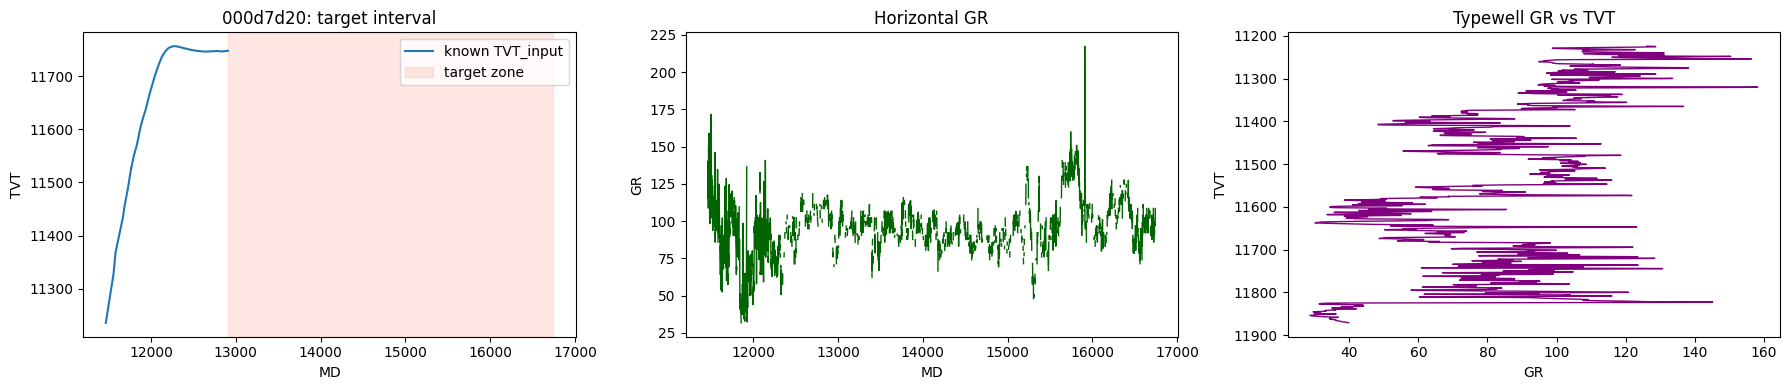

In [5]:
# Visualization
import matplotlib.pyplot as plt

well_id = sample_submission.iloc[0]['id'].rsplit('_', 1)[0]
horizontal_path = data_dir / 'test' / f'{well_id}__horizontal_well.csv'
typewell_path = data_dir / 'test' / f'{well_id}__typewell.csv'
if not horizontal_path.exists():
    horizontal_path = data_dir / 'train' / f'{well_id}__horizontal_well.csv'
    typewell_path = data_dir / 'train' / f'{well_id}__typewell.csv'

hw = pd.read_csv(horizontal_path)
tw = pd.read_csv(typewell_path)
sub_idx = sample_submission[sample_submission.id.str.startswith(well_id + '_')].id.str.rsplit('_', n=1).str[-1].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(hw['MD'], hw['TVT_input'], label='known TVT_input', linewidth=1.5)
if 'TVT' in hw:
    axes[0].plot(hw['MD'], hw['TVT'], label='train TVT', linewidth=1, alpha=0.65)
if len(sub_idx):
    axes[0].axvspan(hw.loc[sub_idx.min(), 'MD'], hw.loc[sub_idx.max(), 'MD'], color='tomato', alpha=0.15, label='target zone')
axes[0].set_title(f'{well_id}: target interval')
axes[0].set_xlabel('MD')
axes[0].set_ylabel('TVT')
axes[0].legend()

axes[1].plot(hw['MD'], hw['GR'], color='darkgreen', linewidth=1)
axes[1].set_title('Horizontal GR')
axes[1].set_xlabel('MD')
axes[1].set_ylabel('GR')

axes[2].plot(tw['GR'], tw['TVT'], color='purple', linewidth=1)
axes[2].invert_yaxis()
axes[2].set_title('Typewell GR vs TVT')
axes[2].set_xlabel('GR')
axes[2].set_ylabel('TVT')
plt.tight_layout()
plt.show()


In [6]:
# Train, save model, and create submission
submission = make_submission(
    data_dir=data_dir,
    output_path=Path(OUTPUT_PATH),
    model_dir=Path(MODEL_DIR),
    max_train_rows=MAX_TRAIN_ROWS,
    calibration_rows=CALIBRATION_ROWS,
    validation_fraction=VALIDATION_FRACTION,
)

display(submission.head())
print(submission.shape)
print(submission.isna().sum())
print(submission['tvt'].describe())


loading train/test files...
train rows=5,092,255, test rows=19,221
usable features: 85
fitting lightgbm on 400,000 rows and 85 features
fitting xgboost on 400,000 rows and 85 features
baseline validation MAE: 11.19376
calibrated validation MAE: 1.81929, alpha=1.00, bias=-0.00139
fitting lightgbm on 800,000 rows and 85 features
fitting xgboost on 800,000 rows and 85 features
wrote submission: submission.csv shape=(14151, 2)
saved model bundle: models\model_artifacts.joblib
saved metadata: models\model_metadata.json


,id,tvt
0,000d7d20_1442,11756.729770
1,000d7d20_1443,11756.729770
2,000d7d20_1444,11757.018315
3,000d7d20_1445,11757.194603
4,000d7d20_1446,11757.208824


(14151, 2)
id     0
tvt    0
dtype: int64
count    14151.000000
mean     11917.301371
std        278.420497
min      11605.854121
25%      11619.330264
50%      11759.819666
75%      12234.246825
max      12249.709381
Name: tvt, dtype: float64


In [7]:
# Check saved model files
from pathlib import Path
import json

print('submission exists:', Path(OUTPUT_PATH).exists(), Path(OUTPUT_PATH).resolve())
print('model bundle exists:', (Path(MODEL_DIR) / 'model_artifacts.joblib').exists())
print('metadata exists:', (Path(MODEL_DIR) / 'model_metadata.json').exists())

metadata = json.loads((Path(MODEL_DIR) / 'model_metadata.json').read_text())
display(metadata)


submission exists: True D:\PyCharm\kaggle_competition_train\3\submission.csv
model bundle exists: True
metadata exists: True


{'version': 'rogii_v3_residual_calibrated',
 'mode': 'residual_model',
 'models': ['lightgbm', 'xgboost'],
 'features': 85,
 'train_rows_total': 5092255,
 'target_rows_total': 3783989,
 'fit_rows_for_calibration': 400000,
 'calibration_rows': 220000,
 'final_train_rows': 800000,
 'baseline_validation_mae': 11.19375991821289,
 'calibrated_validation_mae': 1.8192924118309004,
 'alpha': 1.0,
 'bias': -0.0013860179278708529,
 'residual_clip': [-47.75, 62.000048828125045],
 'submission_rows': 14151,
 'output_path': 'submission.csv'}

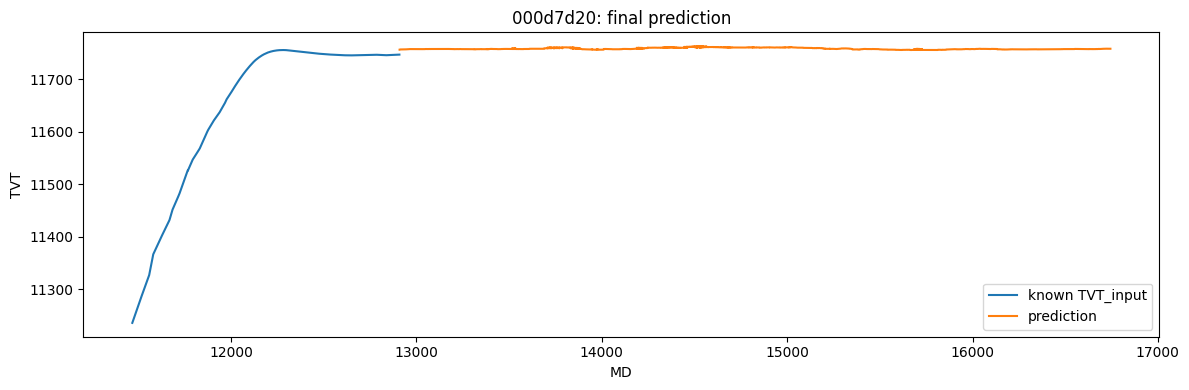

In [8]:
# Visual check of final predictions for one well
pred = submission.copy()
pred['well'] = pred['id'].str.rsplit('_', n=1).str[0]
pred['row_index'] = pred['id'].str.rsplit('_', n=1).str[1].astype(int)
well_id = pred.iloc[0]['well']
hw = pd.read_csv(data_dir / 'test' / f'{well_id}__horizontal_well.csv')
part = pred[pred['well'] == well_id]

plt.figure(figsize=(12, 4))
plt.plot(hw['MD'], hw['TVT_input'], label='known TVT_input', linewidth=1.5)
plt.plot(hw.loc[part['row_index'], 'MD'], part['tvt'], label='prediction', linewidth=1.5)
plt.title(f'{well_id}: final prediction')
plt.xlabel('MD')
plt.ylabel('TVT')
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
# Optional direct submission from Kaggle Notebook
# ??? API key ?? notebook????? Kaggle ?? Submit ? Kaggle Secrets?

COMPETITION = 'rogii-wellbore-geology-prediction'
MESSAGE = 'v3 residual calibrated saved model'
submission_path = Path(OUTPUT_PATH)
assert submission_path.exists(), f'Missing {submission_path}; run the training cell first.'

try:
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    api.authenticate()
    api.competition_submit(str(submission_path), MESSAGE, COMPETITION)
    print('Submitted successfully.')
except Exception as e:
    print('Submit failed:', repr(e))
    print(f'You can submit manually with: kaggle competitions submit -c {COMPETITION} -f {submission_path} -m "{MESSAGE}"')


Submit failed: HTTPError('401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/StartSubmissionUpload')
You can submit manually with: kaggle competitions submit -c rogii-wellbore-geology-prediction -f submission.csv -m "v3 residual calibrated saved model"
